### 가설 3: 신규 고객일수록 초기에 이탈할 확률이 높다

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/insurance_policyholder_churn_synthetic.csv')

print(df.shape)
print(df.columns.tolist())
print(df[["customer_tenure_months", "num_contacts_12m", "churn_flag"]].head())

(50000, 40)
['customer_id', 'as_of_date', 'region_name', 'age', 'age_band', 'marital_status', 'customer_tenure_months', 'multi_policy_flag', 'num_policies', 'policy_type', 'renewal_month', 'current_premium', 'premium_last_year', 'premium_change_pct', 'num_price_increases_last_3y', 'coverage_amount', 'premium_to_coverage_ratio', 'payment_frequency', 'autopay_enabled', 'late_payment_count_12m', 'missed_payment_flag', 'payment_method_change_flag', 'num_claims_12m', 'num_approved_claims_12m', 'num_rejected_claims_12m', 'num_pending_claims_12m', 'avg_claim_amount', 'total_claim_amount_12m', 'total_payout_amount_12m', 'payout_ratio_12m', 'avg_settlement_time_days', 'days_since_last_claim', 'num_contacts_12m', 'complaint_flag', 'complaint_resolution_days', 'quote_requested_flag', 'coverage_downgrade_flag', 'churn_flag', 'churn_type', 'churn_probability_true']
   customer_tenure_months  num_contacts_12m  churn_flag
0                     128                 0           0
1                      

In [5]:
tenure_churn = (
    df.groupby("customer_tenure_months")["churn_flag"]
      .agg(["mean", "count"])
      .reset_index()
)

print(tenure_churn.head(15))

    customer_tenure_months      mean  count
0                        1  0.647436    312
1                        2  0.648551    276
2                        3  0.616197    284
3                        4  0.655303    264
4                        5  0.707581    277
5                        6  0.676991    226
6                        7  0.626556    241
7                        8  0.573077    260
8                        9  0.623616    271
9                       10  0.648438    256
10                      11  0.670330    273
11                      12  0.393822    259
12                      13  0.379747    316
13                      14  0.420139    288
14                      15  0.440741    270


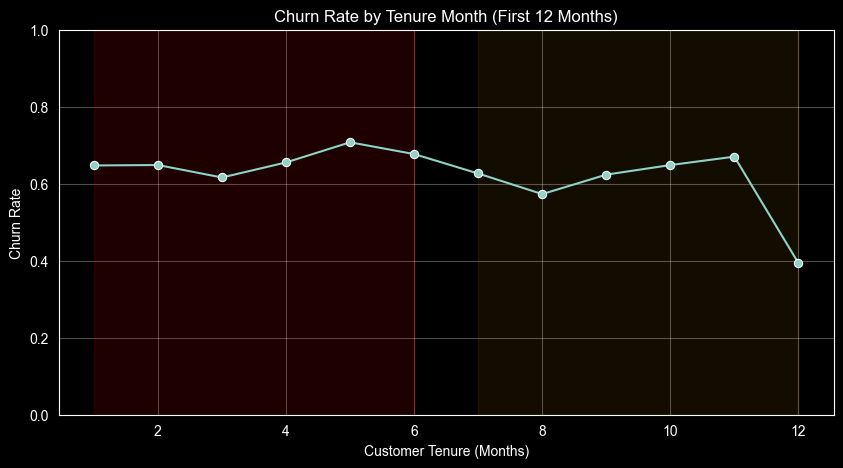

In [6]:
early_tenure_churn = tenure_churn[tenure_churn["customer_tenure_months"] <= 12]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=early_tenure_churn,
    x="customer_tenure_months",
    y="mean",
    marker="o"
)

plt.axvspan(1, 6, color="red", alpha=0.12)
plt.axvspan(7, 12, color="orange", alpha=0.08)

plt.title("Churn Rate by Tenure Month (First 12 Months)")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

In [7]:
new_6m_rate = df[df["customer_tenure_months"] <= 6]["churn_flag"].mean()
new_12m_rate = df[df["customer_tenure_months"] <= 12]["churn_flag"].mean()
old_rate = df[df["customer_tenure_months"] > 12]["churn_flag"].mean()

print("가입 6개월 이내 이탈률 :", round(new_6m_rate, 4))
print("가입 12개월 이내 이탈률 :", round(new_12m_rate, 4))
print("가입 12개월 초과 이탈률 :", round(old_rate, 4))

가입 6개월 이내 이탈률 : 0.6577
가입 12개월 이내 이탈률 : 0.6246
가입 12개월 초과 이탈률 : 0.2796


### 가설 4: 문의 횟수가 많을수록 잠재적 불만족 상태이며 이탈 징후를 보인다

In [8]:
contact_churn = (
    df.groupby("num_contacts_12m")["churn_flag"]
      .agg(["mean", "count"])
      .reset_index()
)

print(contact_churn)

    num_contacts_12m      mean  count
0                  0  0.302572  14076
1                  1  0.297746  17656
2                  2  0.297271  11249
3                  3  0.310504   4760
4                  4  0.318069   1616
5                  5  0.369697    495
6                  6  0.295082    122
7                  7  0.428571     21
8                  8  0.333333      3
9                  9  1.000000      1
10                10  1.000000      1


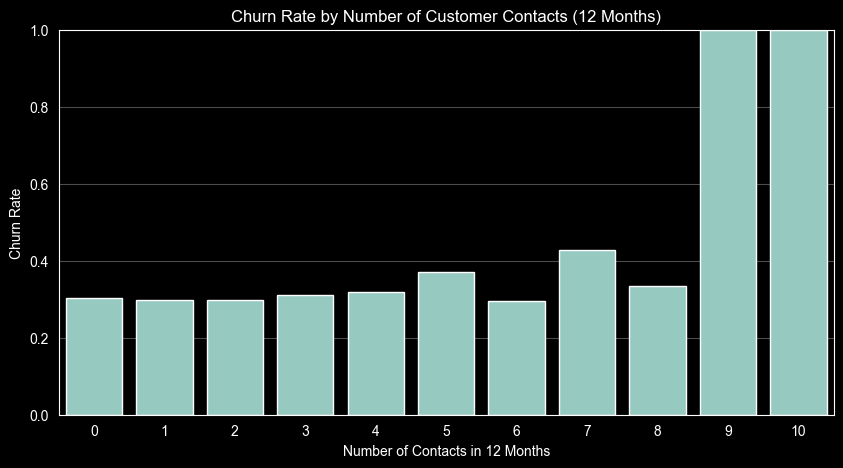

In [9]:
#  문의횟수 와 이탈율
plt.figure(figsize=(10, 5))
sns.barplot(
    data=contact_churn,
    x="num_contacts_12m",
    y="mean"
)

plt.title("Churn Rate by Number of Customer Contacts (12 Months)")
plt.xlabel("Number of Contacts in 12 Months")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

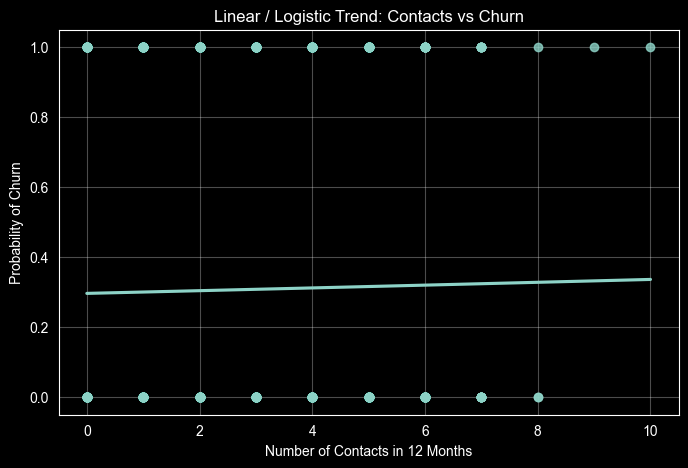

In [10]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="num_contacts_12m",
    y="churn_flag",
    logistic=True,
    ci=None
)

plt.title("Linear / Logistic Trend: Contacts vs Churn")
plt.xlabel("Number of Contacts in 12 Months")
plt.ylabel("Probability of Churn")
plt.grid(alpha=0.3)
plt.show()

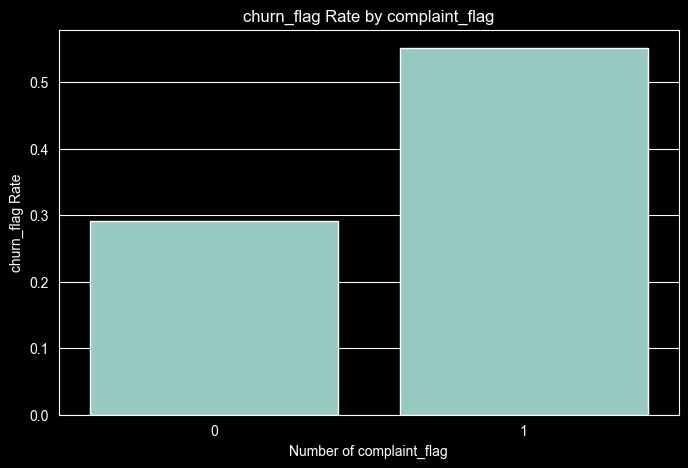

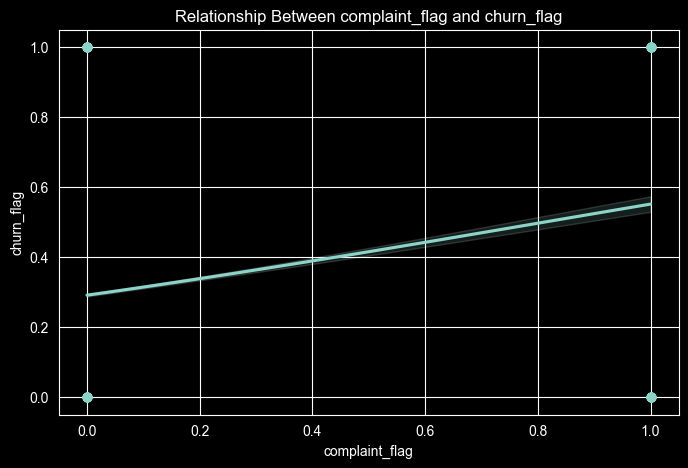

In [12]:
support_churn = df.groupby('complaint_flag')['churn_flag'].mean().reset_index()

# barplot이 관계를 보기 가장 좋다.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
data=support_churn,
x='complaint_flag',
y='churn_flag'
)

plt.title("churn_flag Rate by complaint_flag")
plt.xlabel("Number of complaint_flag")
plt.ylabel("churn_flag Rate")

plt.show()

plt.figure(figsize=(8,5))

sns.regplot(
data=df,
x='complaint_flag',
y='churn_flag',
logistic=True
)

plt.title("Relationship Between complaint_flag and churn_flag")

plt.show()

# 설명

logistic=True